## Понижение размерности для задачи классификации

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import umap

from sklearn.ensemble import BaggingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.feature_selection import RFE, VarianceThreshold, SelectKBest
from sklearn.linear_model import ElasticNet
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, Isomap

### Чтение данных

In [2]:
data = pd.read_csv('../data/diamonds_filtered.csv')

y = data['price']
x = data.drop('price', axis=1)

In [4]:
x.head(10)

,carat,cut,color,clarity,depth,table,radius
0,0.29,4,2,4,62.4,58,2.100
1,0.31,2,1,2,63.3,58,2.170
2,0.30,2,1,3,64.0,55,2.125
3,0.31,5,1,2,62.2,54,2.175
4,0.32,4,6,1,60.9,58,2.190
5,0.30,5,2,2,62.0,54,2.155
6,0.30,2,1,3,63.4,54,2.115
7,0.30,2,1,3,63.8,56,2.115
8,0.30,3,1,3,62.7,59,2.105
9,0.30,2,2,2,63.3,56,2.130


In [5]:
y.head(5)

0    334
1    335
2    339
3    344
4    345
Name: price, dtype: int64

In [ ]:
results = []

def test(x_test, y=y):
    pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', BaggingRegressor(
        n_estimators=13,
        max_samples=0.57,
        max_features=0.95,
        random_state=81,
        n_jobs=-1
    ))
])

    kf = KFold(n_splits=5, shuffle=True, random_state=81)
    scores = cross_val_score(pipeline, x_test, y, cv=kf, scoring='r2')
    print(f"Средний R^2: {round(scores.mean(), 4)}")

    return round(scores.mean(), 4)

### Обучение без понижения размерности

In [7]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', BaggingRegressor(
        n_estimators=13,
        max_samples=0.57,
        max_features=0.95,
        random_state=81,
        n_jobs=-1
    ))
])

kf = KFold(n_splits=5, shuffle=True, random_state=81)
scores = cross_val_score(pipeline, x, y, cv=kf, scoring='r2')
print(f"Средний R^2: {round(scores.mean(), 4)}")

Средний R^2: 0.9802


### Отбор признаков с высокой дисперсией (VarianceThreshold)

In [8]:
x.describe()

,carat,cut,color,clarity,depth,table,radius
count,48488.000000,48488.000000,48488.000000,48488.000000,48488.000000,48488.000000,48488.000000
mean,0.762472,4.026171,4.437118,4.092518,61.788275,57.272109,2.836399
std,0.413451,1.014220,1.685800,1.628100,1.102768,2.026928,0.514817
min,0.270000,1.000000,1.000000,1.000000,58.800000,52.000000,2.070000
25%,0.400000,3.000000,3.000000,3.000000,61.100000,56.000000,2.355000
50%,0.700000,4.000000,4.000000,4.000000,61.900000,57.000000,2.835000
75%,1.030000,5.000000,6.000000,5.000000,62.500000,59.000000,3.245000
max,2.040000,5.000000,7.000000,8.000000,64.700000,63.000000,4.090000


In [9]:
variances = x.var().sort_values()
variances

carat      0.170942
radius     0.265037
cut        1.028642
depth      1.216097
clarity    2.650710
color      2.841922
table      4.108437
dtype: float64

In [10]:
vt  = VarianceThreshold(0.2)
x_vt = vt.fit_transform(x)

x_vt = pd.DataFrame(x_vt, columns=vt.get_feature_names_out())
x_vt.head()

,cut,color,clarity,depth,table,radius
0,4.0,2.0,4.0,62.4,58.0,2.100
1,2.0,1.0,2.0,63.3,58.0,2.170
2,2.0,1.0,3.0,64.0,55.0,2.125
3,5.0,1.0,2.0,62.2,54.0,2.175
4,4.0,6.0,1.0,60.9,58.0,2.190


In [11]:
r2_vt = test(x_test=x_vt)

Средний R^2: 0.9078


In [12]:
results.append({"Method": "VarianceThreshold", "R^2": r2_vt})

### Одномерный отбор признаков (SelectKBest)

In [13]:
skb = SelectKBest(k=4)
x_skb = skb.fit_transform(x, y)

r2_skb = test(x_skb)

Средний R^2: 0.9689


In [14]:
results.append({"Method": "SelectKBest", "R^2": r2_skb})

In [15]:
x_skb = pd.DataFrame(x_skb, columns=skb.get_feature_names_out())
x_skb.head()

,carat,color,clarity,radius
0,0.29,2.0,4.0,2.100
1,0.31,1.0,2.0,2.170
2,0.30,1.0,3.0,2.125
3,0.31,1.0,2.0,2.175
4,0.32,6.0,1.0,2.190


### Рекурсивный отбор признаков (RFE)

In [16]:
regressor = ElasticNet().fit(x, y)

rfe = RFE(estimator=regressor, n_features_to_select=4, step=1).fit(x, y)
x_rfe = pd.DataFrame(rfe.transform(x), columns=rfe.get_feature_names_out())
r2_rfe = test(x_rfe)

Средний R^2: 0.9184


In [17]:
results.append({"Method": "RFE", "R^2": r2_rfe})

In [18]:
x_rfe.head()

,carat,clarity,table,radius
0,0.29,4.0,58.0,2.100
1,0.31,2.0,58.0,2.170
2,0.30,3.0,55.0,2.125
3,0.31,2.0,54.0,2.175
4,0.32,1.0,58.0,2.190


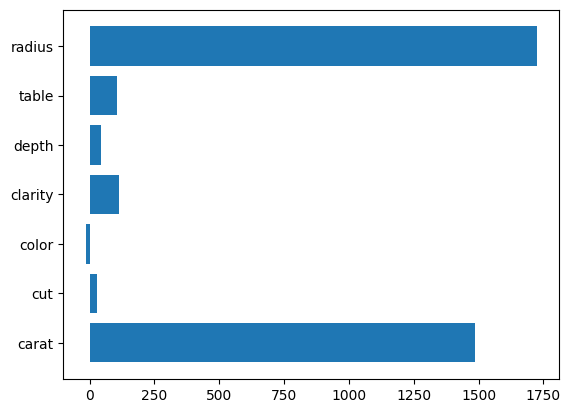

In [19]:
plt.barh(width=regressor.coef_, y=x.columns);

### Метод главных компонент (PCA)

In [20]:
pca_4 = PCA(n_components=4)
x_pca_4 = pd.DataFrame(pca_4.fit_transform(x, y), columns=pca_4.get_feature_names_out())

r2_pca_4 = test(x_pca_4)

Средний R^2: 0.6234


In [21]:
print(f"Сохранено информации {round(sum(pca_4.explained_variance_ratio_), 4)}")
x_pca_4.head()

Сохранено информации 0.929


,pca0,pca1,pca2,pca3
0,0.632346,2.236499,-0.730193,0.340488
1,1.626311,2.438966,-3.132591,1.661391
2,-1.495464,2.555766,-3.310375,2.351509
3,-2.613050,2.136805,-3.811044,-1.016856
4,1.564393,-2.542746,-1.544862,-1.188712


In [22]:
results.append({"Method": "PCA", "R^2": r2_pca_4})

In [23]:
pca_3 = PCA(n_components=3)
x_pca_3 = pca_3.fit_transform(x, y)

r2_pca_3 = test(x_pca_3)

Средний R^2: 0.355


In [24]:
print(f"Сохранено информации {round(sum(pca_3.explained_variance_ratio_), 4)}")

Сохранено информации 0.8168


#### KernelPCA

In [25]:
k_pca_poly = KernelPCA(n_components=4, kernel='poly')

x_pca_poly = k_pca_poly.fit_transform(x.head(30_000))
x_pca_poly = pd.DataFrame(x_pca_poly, columns=k_pca_poly.get_feature_names_out())

r2_k_pca_poly = test(x_test=x_pca_poly, y=y.head(30_000))

Средний R^2: 0.6687


In [26]:
k_pca_rbf = KernelPCA(n_components=4, kernel='rbf')

x_pca_rbf = k_pca_rbf.fit_transform(x.head(30_000))
x_pca_rbf = pd.DataFrame(x_pca_rbf, columns=k_pca_rbf.get_feature_names_out())

r2_k_pca_rbf = test(x_test=x_pca_rbf, y=y.head(30_000))

Средний R^2: 0.426


In [27]:
k_pca_sigmoid = KernelPCA(n_components=4, kernel='sigmoid')

x_pca_sigmoid = k_pca_sigmoid.fit_transform(x.head(30_000))
x_pca_sigmoid = pd.DataFrame(x_pca_sigmoid, columns=k_pca_sigmoid.get_feature_names_out())

r2_k_pca_sigmoid = test(x_test=x_pca_sigmoid, y=y.head(30_000))

Средний R^2: -0.0001


### Нелинейные методы выбора признаков

#### TSNE

In [6]:
tsne = TSNE(n_components=3)
x_tsne = tsne.fit_transform(x.head(10_000))
x_tsne = pd.DataFrame(x_tsne)

r2_tsne = test(x_test=x.head(10_000), y=y.head(10_000))

Средний R^2: 0.9341


In [ ]:
results.append({"Method": "TSNE", "R^2": r2_tsne})

In [7]:
x_tsne.head()

,0,1,2
0,-0.590144,18.381367,6.937015
1,6.904068,18.172672,-11.141665
2,-3.740082,6.818837,-12.121466
3,-19.874649,15.704020,3.629030
4,3.425516,-24.276897,-2.096260


#### Isomap

In [5]:
isomap = Isomap(n_components=3)
x_isomap = isomap.fit_transform(x.head(10_000))
x_isomap = pd.DataFrame(x_isomap)


r2_isomap = test(x_test=x.head(10_000), y=y.head(10_000))

/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/sklearn/manifold/_isomap.py:383: UserWarning: The number of connected components of the neighbors graph is 5 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/scipy/sparse/_index.py:100: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/scipy/sparse/_index.py:100: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])
/Users/irinaaristova/Documents/Programming/ml-learning/venv/lib/python3.9/site-packages/scipy/sparse/_index.py:100: Spars

Средний R^2: 0.9341


In [ ]:
results.append({"Method": "Isomap", "R^2": r2_isomap})

In [8]:
x_tsne.head()

,0,1,2
0,-0.590144,18.381367,6.937015
1,6.904068,18.172672,-11.141665
2,-3.740082,6.818837,-12.121466
3,-19.874649,15.704020,3.629030
4,3.425516,-24.276897,-2.096260


#### UMAP

In [4]:
reducer = umap.UMAP(n_components=4, n_jobs=-1)
x_umap_values = reducer.fit_transform(x)

x_umap = pd.DataFrame(x_umap_values, columns=[f'umap_{i}' for i in range(x_umap_values.shape[1])])

r2_umap = test(x_umap)

Средний R^2: 0.6256


In [9]:
results.append({"Method": "UMAP", "R^2": round(r2_umap, 4)})

NameError: name 'results' is not defined